In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
import gensim
import warnings

warnings.filterwarnings("ignore")

## DATA PREPROCESING

In [2]:
train=pd.read_csv("data train test validate/train.txt",sep=';',names=["text","emotion"])
test=pd.read_csv("data train test validate/test.txt",sep=";",names=["text","emotion"])

In [3]:
train.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
test.head()

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [5]:
# check for missing values
train.isnull().sum()

text       0
emotion    0
dtype: int64

In [6]:
test.isnull().sum()

text       0
emotion    0
dtype: int64

In [7]:
# checking for duplicate values 
print(train.isnull().sum())
print(test.isnull().sum())

text       0
emotion    0
dtype: int64
text       0
emotion    0
dtype: int64


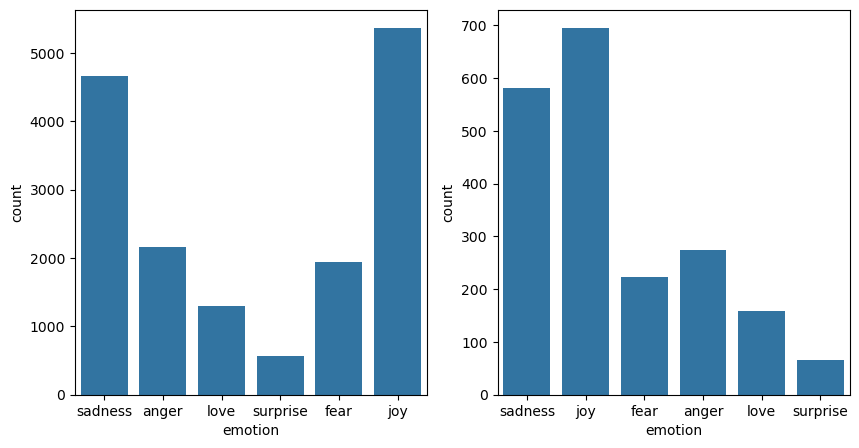

In [8]:
fig,axes=plt.subplots(1,2,figsize=(10,5))
#train count plot 
sns.countplot(x=train["emotion"],ax=axes[0])

sns.countplot(x=test["emotion"],ax=axes[1])
plt.show()

In [9]:
train["emotion"].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [10]:
test["emotion"].value_counts()

emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

In [11]:
# info 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     2000 non-null   object
 1   emotion  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [19]:
# Basic preprocessing steps 

In [20]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import contractions

In [21]:
# stop words'Stemmer'Lemmatizer
stop_words=set(stopwords.words('english'))

ps=PorterStemmer()

lemmatizer=WordNetLemmatizer()

In [22]:
# Creating a Single Cleaning Function 

In [23]:
def clean_text(text):
    #lower_case
    text=text.lower()

    # contractions 
    text=contractions.fix(text)
    #removing URL
    text=re.sub(r'http\S+','',text)
    
    # remove punctuation and number 
    text=re.sub(r'[^a-zA-Z\s]','',text)
    
    #tokenization
    words=word_tokenize(text)
    
    #stop word removal
    words=[word for word in words if word not in stop_words]
    
    #Lemmatization
    words=[lemmatizer.lemmatize(word) for word in words]

    # join 
    return " ".join(words)

    
    

In [24]:
# train data cleaning 
train["clean_text"]=train["text"].apply(clean_text)

In [25]:
train.head(20)

,text,emotion,clean_text
0,i didnt feel humiliated,sadness,feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,feeling grouchy
5,ive been feeling a little burdened lately wasn...,sadness,feeling little burdened lately sure
6,ive been taking or milligrams or times recomme...,surprise,taking milligram time recommended amount falle...
7,i feel as confused about life as a teenager or...,fear,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,joy,petronas year feel petronas performed well mad...
9,i feel romantic too,love,feel romantic


In [26]:
# Test Data cleaning 
test["clean_text"]=test["text"].apply(clean_text)

In [27]:
train["word_count"]=train["clean_text"].apply(lambda x:len(x.split()))

In [28]:
test.head()

,text,emotion,clean_text
0,im feeling rather rotten so im not very ambiti...,sadness,feeling rather rotten ambitious right
1,im updating my blog because i feel shitty,sadness,updating blog feel shitty
2,i never make her separate from me because i do...,sadness,never make separate ever want feel like ashamed
3,i left with my bouquet of red and yellow tulip...,joy,left bouquet red yellow tulip arm feeling slig...
4,i was feeling a little vain when i did this one,sadness,feeling little vain one


In [29]:
# Train EDA 
train["word_count"].describe()

count    16000.000000
mean         9.034500
std          5.082819
min          1.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         35.000000
Name: word_count, dtype: float64

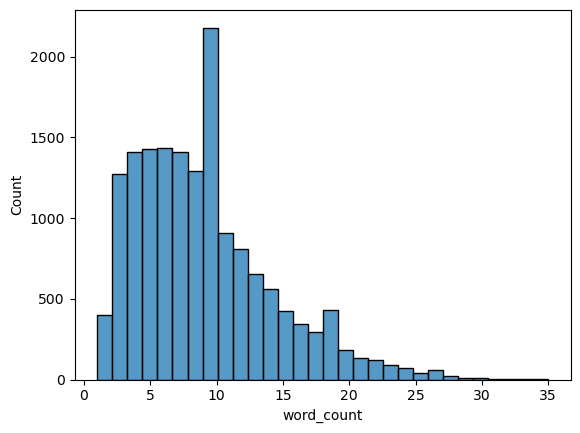

In [30]:
sns.histplot(train["word_count"],bins=30)
plt.show()

In [31]:
# Test Eda 
test["word_count"]=test["clean_text"].apply(lambda x:len(x.split()))
test["word_count"].describe()

count    2000.000000
mean        8.990500
std         5.031408
min         2.000000
25%         5.000000
50%         8.000000
75%        12.000000
max        29.000000
Name: word_count, dtype: float64

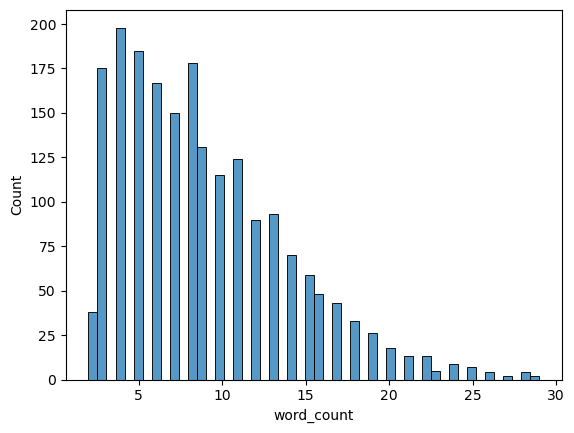

In [32]:
sns.histplot(test["word_count"],bins=50)
plt.show()

# Seprate Feature and Target (Test and Train))

In [33]:
# TRAIN SEPRATION
X_train=train["clean_text"]
y_train=train["emotion"]

In [34]:
#TEST SEPRATION
X_test=test["clean_text"]
y_test=test["emotion"]

# LABEL ENCODING OF TARGET VARIABLE

In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

y_train_en=le.fit_transform(y_train)
y_test_en=le.transform(y_test)

# FEATURE ENGINEERING 

### BAG OF WORDS 

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

In [37]:
bow=CountVectorizer()
#X_train
X_train_bow=bow.fit_transform(X_train)

# X_test 
X_test_bow=bow.transform(X_test)

In [38]:
print(len(bow.vocabulary_))
print(X_train_bow.shape)
print(bow.get_feature_names_out())
print(X_test_bow.toarray()[:10])

13390
(16000, 13390)
['aa' 'aaaaaaand' 'aaaaand' ... 'zum' 'zumba' 'zz']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [39]:
word_count=np.array(X_train_bow.sum(axis=0)).flatten()

word= bow.get_feature_names_out()

freq=pd.DataFrame({"WORD":word,"COUNT":word_count})

freq.sort_values("COUNT",ascending=False)[:20]

,WORD,COUNT
4348,feel,11506
4352,feeling,5455
6830,like,2918
11969,time,974
9502,really,942
6560,know,884
4924,get,778
7119,make,769
6891,little,736
13230,would,717


### 1.BOW Vectorization

#### Model 1.1 : Logistic Regression (BOW)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [41]:
lr=LogisticRegression(max_iter=1000,random_state=42)

# fitting 
lr.fit(X_train_bow,y_train_en)

# predict on test and train 
y_train_predict_lr=lr.predict(X_train_bow)
y_test_predict_lr= lr.predict(X_test_bow)

#Accuracy 
train_accuracy_lr= accuracy_score(y_train_en,y_train_predict_lr)
test_accuracy_lr =accuracy_score(y_test_en,y_test_predict_lr)

print("Train Accuracy:",train_accuracy_lr)
print("\n")
print("Test Accuracy:",test_accuracy_lr)

print("\n")

#Confusion Matrix 
cm_lr=confusion_matrix(y_test_en,y_test_predict_lr)
print("Confusion_matrix")
print(cm_lr)

print("\n")

#classification Report
cr_lr=classification_report(y_test_en,y_test_predict_lr)
print("Classification_Report")
print(cr_lr)

Train Accuracy: 0.98375


Test Accuracy: 0.8915


Confusion_matrix
[[241   9   9   1  15   0]
 [  9 189   4   1  16   5]
 [  6   4 645  30   5   5]
 [  3   1  32 120   2   1]
 [ 14   6  11   2 547   1]
 [  1  14   8   0   2  41]]


Classification_Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       275
           1       0.85      0.84      0.85       224
           2       0.91      0.93      0.92       695
           3       0.78      0.75      0.77       159
           4       0.93      0.94      0.94       581
           5       0.77      0.62      0.69        66

    accuracy                           0.89      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.89      0.89      0.89      2000



#### Model 1.2 XGBOOST(BOW)

In [42]:
from xgboost import XGBClassifier

In [43]:
xgb=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=200,
                  max_depth=6,learning_rate=0.1,random_state=42)

In [44]:
xgb.fit(X_train_bow,y_train_en)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [45]:
# predict on test and train 
y_train_predict_xgb=xgb.predict(X_train_bow)
y_test_predict_xgb= xgb.predict(X_test_bow)

#Accuracy 
train_accuracy_xgb= accuracy_score(y_train_en,y_train_predict_xgb)
test_accuracy_xgb =accuracy_score(y_test_en,y_test_predict_xgb)

print("Train Accuracy:",train_accuracy_xgb)
print("\n")
print("Test Accuracy:",test_accuracy_xgb)

print("\n")

#Confusion Matrix 
cm_xgb=confusion_matrix(y_test_en,y_test_predict_xgb)
print("Confusion_matrix")
print(cm_xgb)

print("\n")

#classification Report
cr_xgb=classification_report(y_test_en,y_test_predict_xgb)
print("Classification_Report")
print(cr_xgb)

Train Accuracy: 0.9206875


Test Accuracy: 0.878


Confusion_matrix
[[235   9  21   1   8   1]
 [  4 195   4   0   7  14]
 [  3   4 631  43   6   8]
 [  2   0  26 129   0   2]
 [ 12   5  33   4 522   5]
 [  0  10  12   0   0  44]]


Classification_Report
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       275
           1       0.87      0.87      0.87       224
           2       0.87      0.91      0.89       695
           3       0.73      0.81      0.77       159
           4       0.96      0.90      0.93       581
           5       0.59      0.67      0.63        66

    accuracy                           0.88      2000
   macro avg       0.82      0.83      0.83      2000
weighted avg       0.88      0.88      0.88      2000



#### Model 1.3 Linear SVM(BOW)

In [46]:
from sklearn.svm import LinearSVC

In [47]:
svm=LinearSVC(random_state=42)

In [48]:
svm.fit(X_train_bow,y_train_en)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [49]:
# predict on test and train 
y_train_predict_svm=svm.predict(X_train_bow)
y_test_predict_svm= svm.predict(X_test_bow)

#Accuracy 
train_accuracy_svm= accuracy_score(y_train_en,y_train_predict_svm)
test_accuracy_svm =accuracy_score(y_test_en,y_test_predict_svm)

print("Train Accuracy:",train_accuracy_svm)
print("\n")
print("Test Accuracy:",test_accuracy_svm)

print("\n")

#Confusion Matrix 
cm_svm=confusion_matrix(y_test_en,y_test_predict_svm)
print("Confusion_matrix")
print(cm_svm)

print("\n")

#classification Report
cr_svm=classification_report(y_test_en,y_test_predict_svm)
print("Classification_Report")
print(cr_svm)

Train Accuracy: 0.9929375


Test Accuracy: 0.8885


Confusion_matrix
[[237   7   7   4  19   1]
 [  9 193   3   0  15   4]
 [  4   5 637  36   6   7]
 [  3   3  27 123   1   2]
 [ 16   7  14   2 541   1]
 [  2  11   5   0   2  46]]


Classification_Report
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       275
           1       0.85      0.86      0.86       224
           2       0.92      0.92      0.92       695
           3       0.75      0.77      0.76       159
           4       0.93      0.93      0.93       581
           5       0.75      0.70      0.72        66

    accuracy                           0.89      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.89      0.89      0.89      2000



### 2.TFIDF (Vectorization)

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [51]:
tfidf=TfidfVectorizer()

In [52]:
# Train Vectorizer
X_train_tfidf=tfidf.fit_transform(X_train)

#Test Vectorizer

X_test_tfidf=tfidf.transform(X_test)

#### 2.Modelling with tfidf vectorization 

#### 2.1 Logistic Regression (tfidf)

In [53]:
lr_tf=LogisticRegression(max_iter=1000,random_state=42)

# fitting 
lr_tf.fit(X_train_tfidf,y_train_en)

# predict on test and train 
y_train_predict_lr_tf=lr_tf.predict(X_train_tfidf)
y_test_predict_lr_tf= lr_tf.predict(X_test_tfidf)

#Accuracy 
train_accuracy_lr_tf= accuracy_score(y_train_en,y_train_predict_lr_tf)
test_accuracy_lr_tf =accuracy_score(y_test_en,y_test_predict_lr_tf)

print("Train Accuracy:",train_accuracy_lr_tf)
print("\n")
print("Test Accuracy:",test_accuracy_lr_tf)

print("\n")

#Confusion Matrix 
cm_lr_tf=confusion_matrix(y_test_en,y_test_predict_lr_tf)
print("Confusion_matrix")
print(cm_lr_tf)

print("\n")

#classification Report
cr_lr_tf=classification_report(y_test_en,y_test_predict_lr_tf)
print("Classification_Report")
print(cr_lr_tf)

Train Accuracy: 0.94575


Test Accuracy: 0.873


Confusion_matrix
[[228   6  19   1  21   0]
 [  9 181  11   0  22   1]
 [  4   4 662  19   5   1]
 [  3   0  48 100   8   0]
 [ 13   4  22   1 541   0]
 [  1  13  14   0   4  34]]


Classification_Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       275
           1       0.87      0.81      0.84       224
           2       0.85      0.95      0.90       695
           3       0.83      0.63      0.71       159
           4       0.90      0.93      0.92       581
           5       0.94      0.52      0.67        66

    accuracy                           0.87      2000
   macro avg       0.88      0.78      0.81      2000
weighted avg       0.87      0.87      0.87      2000



#### Model 2.2 XGBOOST USING (TFIDF)

In [54]:
xgb_tf=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=200,
                  max_depth=6,learning_rate=0.1,random_state=42)



In [55]:
xgb_tf.fit(X_train_tfidf,y_train_en)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [56]:
# predict on test and train 
y_train_predict_xgb_tf=xgb_tf.predict(X_train_tfidf)
y_test_predict_xgb_tf= xgb_tf.predict(X_test_tfidf)

#Accuracy 
train_accuracy_xgb_tf= accuracy_score(y_train_en,y_train_predict_xgb_tf)
test_accuracy_xgb_tf =accuracy_score(y_test_en,y_test_predict_xgb_tf)

print("Train Accuracy:",train_accuracy_xgb_tf)
print("\n")
print("Test Accuracy:",test_accuracy_xgb_tf)

print("\n")

#Confusion Matrix 
cm_xgb_tf=confusion_matrix(y_test_en,y_test_predict_xgb_tf)
print("Confusion_matrix")
print(cm_xgb_tf)

print("\n")

#classification Report
cr_xgb_tf=classification_report(y_test_en,y_test_predict_xgb_tf)
print("Classification_Report")
print(cr_xgb_tf)

Train Accuracy: 0.936875


Test Accuracy: 0.878


Confusion_matrix
[[235   8  21   1   9   1]
 [  4 199   4   0   5  12]
 [  3   4 631  43   6   8]
 [  2   0  28 127   0   2]
 [ 12   6  37   3 518   5]
 [  0  10  10   0   0  46]]


Classification_Report
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       275
           1       0.88      0.89      0.88       224
           2       0.86      0.91      0.88       695
           3       0.73      0.80      0.76       159
           4       0.96      0.89      0.93       581
           5       0.62      0.70      0.66        66

    accuracy                           0.88      2000
   macro avg       0.83      0.84      0.83      2000
weighted avg       0.88      0.88      0.88      2000



#### Model 2.3 Liner svm (TFIDF)

In [57]:
svm_tf=LinearSVC(random_state=42)

In [58]:
svm_tf.fit(X_train_tfidf,y_train_en)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [59]:
# predict on test and train 
y_train_predict_svm_tf=svm_tf.predict(X_train_tfidf)
y_test_predict_svm_tf= svm_tf.predict(X_test_tfidf)

#Accuracy 
train_accuracy_svm_tf= accuracy_score(y_train_en,y_train_predict_svm_tf)
test_accuracy_svm_tf =accuracy_score(y_test_en,y_test_predict_svm_tf)

print("Train Accuracy:",train_accuracy_svm_tf)
print("\n")
print("Test Accuracy:",test_accuracy_svm_tf)

print("\n")

#Confusion Matrix 
cm_svm_tf=confusion_matrix(y_test_en,y_test_predict_svm_tf)
print("Confusion_matrix")
print(cm_svm_tf)

print("\n")

#classification Report
cr_svm_tf=classification_report(y_test_en,y_test_predict_svm_tf)
print("Classification_Report")
print(cr_svm_tf)

Train Accuracy: 0.9858125


Test Accuracy: 0.893


Confusion_matrix
[[242   6   8   2  16   1]
 [ 10 189   4   0  18   3]
 [  4   3 643  32   5   8]
 [  2   0  28 126   2   1]
 [ 18   5  14   1 542   1]
 [  1  12   6   0   3  44]]


Classification_Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       275
           1       0.88      0.84      0.86       224
           2       0.91      0.93      0.92       695
           3       0.78      0.79      0.79       159
           4       0.92      0.93      0.93       581
           5       0.76      0.67      0.71        66

    accuracy                           0.89      2000
   macro avg       0.86      0.84      0.85      2000
weighted avg       0.89      0.89      0.89      2000



### 3.WORD2VEC (Vectorization)

In [60]:
# tokenize train and test before word2vec

tokenized_train=[sentence.split() for sentence in X_train]

tokenized_test=[sentence.split() for sentence in X_test]

In [61]:
from gensim.models import Word2Vec

In [62]:
w2v=Word2Vec(sentences=tokenized_train,vector_size=100,window=5,min_count=2,workers=4)

In [63]:
w2v.wv["happy"]

array([-0.03389692,  0.3535829 ,  0.35580978,  0.352796  , -0.00572796,
       -0.8853851 ,  0.19142203,  0.8503394 , -0.15852177, -0.2536828 ,
       -0.3084289 , -0.55603594, -0.0646231 ,  0.6055513 ,  0.20980468,
       -0.34115237,  0.25247365, -0.38452724, -0.20895979, -0.8108144 ,
        0.35610488,  0.30532765,  0.56116444, -0.32498768, -0.09811284,
       -0.0672148 , -0.5112553 , -0.25014833, -0.53624696,  0.28859672,
        0.4363234 ,  0.03042523,  0.1585105 , -0.2741878 , -0.31901065,
        0.3402407 ,  0.2001263 , -0.44239765, -0.28214973, -0.67438704,
       -0.09787277, -0.3649161 , -0.3370348 ,  0.02762335,  0.3617528 ,
       -0.26765606, -0.4974688 ,  0.1215634 ,  0.30648825,  0.37287536,
        0.1390178 , -0.31550464, -0.10582332, -0.01062414, -0.2427194 ,
        0.22846486,  0.2835394 , -0.06722619, -0.5430902 ,  0.24685255,
        0.09276247, -0.03969292, -0.15460794, -0.0356323 , -0.5618439 ,
        0.5624854 , -0.14747535,  0.4591757 , -0.5668699 ,  0.49

In [64]:
def document_vector(doc):
    words=doc.split()

    vectors= [w2v.wv[word] for word in words if word in w2v.wv]

    if len(vectors)==0:
        return np.zeros(100)
    return np.mean(vectors,axis=0)

In [65]:
X_train_w2v=np.array([document_vector(doc) for doc in X_train])

X_test_w2v=np.array([document_vector(doc) for doc in X_test])

In [66]:
X_train_w2v.shape

(16000, 100)

#### 3.1 Logistic Regression (W2V VECTORIZATION)

In [67]:
lr_w2v=LogisticRegression(max_iter=1000,random_state=42)

# fitting 
lr_w2v.fit(X_train_w2v,y_train_en)

# predict on test and train 
y_train_predict_lr_w2v=lr_w2v.predict(X_train_w2v)
y_test_predict_lr_w2v= lr_w2v.predict(X_test_w2v)

#Accuracy 
train_accuracy_lr_w2v= accuracy_score(y_train_en,y_train_predict_lr_w2v)
test_accuracy_lr_w2v =accuracy_score(y_test_en,y_test_predict_lr_w2v)

print("Train Accuracy:",train_accuracy_lr_w2v)
print("\n")
print("Test Accuracy:",test_accuracy_lr_w2v)

print("\n")

#Confusion Matrix 
cm_lr_w2v=confusion_matrix(y_test_en,y_test_predict_lr_w2v)
print("Confusion_matrix")
print(cm_lr_w2v)

print("\n")

#classification Report
cr_lr_w2v=classification_report(y_test_en,y_test_predict_lr_w2v)
print("Classification_Report")
print(cr_lr_w2v)

Train Accuracy: 0.36225


Test Accuracy: 0.3815


Confusion_matrix
[[  0   0 208   0  67   0]
 [  0   0 156   0  68   0]
 [  0   0 595   0 100   0]
 [  0   0 136   0  23   0]
 [  0   0 413   0 168   0]
 [  0   0  45   0  21   0]]


Classification_Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       275
           1       0.00      0.00      0.00       224
           2       0.38      0.86      0.53       695
           3       0.00      0.00      0.00       159
           4       0.38      0.29      0.33       581
           5       0.00      0.00      0.00        66

    accuracy                           0.38      2000
   macro avg       0.13      0.19      0.14      2000
weighted avg       0.24      0.38      0.28      2000



#### 3.2 XGBOOST(W2V Vectorization)

In [68]:
xgb_w2v=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=200,
                  max_depth=6,learning_rate=0.1,random_state=42)

In [69]:
xgb_w2v.fit(X_train_w2v,y_train_en)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [70]:
# predict on test and train 
y_train_predict_xgb_w2v=xgb_w2v.predict(X_train_w2v)
y_test_predict_xgb_w2v= xgb_w2v.predict(X_test_w2v)

#Accuracy 
train_accuracy_xgb_w2v= accuracy_score(y_train_en,y_train_predict_xgb_w2v)
test_accuracy_xgb_w2v =accuracy_score(y_test_en,y_test_predict_xgb_w2v)

print("Train Accuracy:",train_accuracy_xgb_w2v)
print("\n")
print("Test Accuracy:",test_accuracy_xgb_w2v)

print("\n")

#Confusion Matrix 
cm_xgb_w2v=confusion_matrix(y_test_en,y_test_predict_xgb_w2v)
print("Confusion_matrix")
print(cm_xgb_w2v)

print("\n")

#classification Report
cr_xgb_w2v=classification_report(y_test_en,y_test_predict_xgb_w2v)
print("Classification_Report")
print(cr_xgb_w2v)

Train Accuracy: 0.82375


Test Accuracy: 0.381


Confusion_matrix
[[  9   7 143   0 116   0]
 [ 11  10 106   1  96   0]
 [ 15   5 475   5 193   2]
 [  3   1 102   3  50   0]
 [ 16  15 285   2 263   0]
 [  3   3  37   0  21   2]]


Classification_Report
              precision    recall  f1-score   support

           0       0.16      0.03      0.05       275
           1       0.24      0.04      0.08       224
           2       0.41      0.68      0.52       695
           3       0.27      0.02      0.04       159
           4       0.36      0.45      0.40       581
           5       0.50      0.03      0.06        66

    accuracy                           0.38      2000
   macro avg       0.32      0.21      0.19      2000
weighted avg       0.33      0.38      0.32      2000



#### 3.3 Liner SVM (W2V VECTORIZATION)

In [71]:
svm_w2v=LinearSVC(random_state=42)

In [72]:
svm_w2v.fit(X_train_w2v,y_train_en)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [73]:
# predict on test and train 
y_train_predict_svm_w2v=svm_w2v.predict(X_train_w2v)
y_test_predict_svm_w2v= svm_w2v.predict(X_test_w2v)

#Accuracy 
train_accuracy_svm_w2v= accuracy_score(y_train_en,y_train_predict_svm_w2v)
test_accuracy_svm_w2v =accuracy_score(y_test_en,y_test_predict_svm_w2v)

print("Train Accuracy:",train_accuracy_svm_w2v)
print("\n")
print("Test Accuracy:",test_accuracy_svm_w2v)

print("\n")

#Confusion Matrix 
cm_svm_w2v=confusion_matrix(y_test_en,y_test_predict_svm_w2v)
print("Confusion_matrix")
print(cm_svm_w2v)

print("\n")

#classification Report
cr_svm_w2v=classification_report(y_test_en,y_test_predict_svm_w2v)
print("Classification_Report")
print(cr_svm_w2v)

Train Accuracy: 0.386875


Test Accuracy: 0.406


Confusion_matrix
[[  0   0 189   0  86   0]
 [  0   0 147   0  77   0]
 [  0   0 580   0 115   0]
 [  0   0 127   0  32   0]
 [  0   0 349   0 232   0]
 [  0   0  45   0  21   0]]


Classification_Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       275
           1       0.00      0.00      0.00       224
           2       0.40      0.83      0.54       695
           3       0.00      0.00      0.00       159
           4       0.41      0.40      0.41       581
           5       0.00      0.00      0.00        66

    accuracy                           0.41      2000
   macro avg       0.14      0.21      0.16      2000
weighted avg       0.26      0.41      0.31      2000



# Hyper Parameter Tuning Using RANDOMIZED SEARCH CV 

####  XGBOOST-TFIDF 

In [74]:
from sklearn.model_selection import RandomizedSearchCV

In [75]:
xgb_tune=XGBClassifier(objective="multi:softmax",num_class=len(set(y_train_en)),random_state=42)

In [76]:
param_dist={ 'n_estimators':[100,200,300,400,500],
             'max_depth':[3,4,5,6,7,8,9,10,11],
             'learning_rate':[0.01,0.05,0.1,0.2,0.3],
             'subsample':[0.7,0.8,0.9,1.0],
             'colsample_bytree':[0.7,0.8,0.9,1.0],
             'min_child_weight':[1,3,5,7],
             'gamma':[0,0.1,0.2,0.3]
           }



In [77]:
random_search=RandomizedSearchCV(estimator=xgb_tune,param_distributions=param_dist,n_iter=30,
                                 cv=5,scoring='accuracy',verbose=2,random_state=42,n_jobs=-1)

In [78]:
random_search.fit(X_train_tfidf,y_train_en)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBClassifier..._class=6, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [79]:
print("Best Parameters")
print(random_search.best_params_)
print("="*50)
print("Best Score")
print(random_search.best_score_)

Best Parameters
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.3, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best Score
0.8835000000000001


####  Model using Tuned Parameters

In [82]:
xgb_tf_tuned=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=250,
    learning_rate=0.3,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight=3,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42)

xgb_tf_tuned.fit(X_train_tfidf,y_train_en)

# predict on test and train 
y_train_predict_xgb_tf_tuned=xgb_tf_tuned.predict(X_train_tfidf)
y_test_predict_xgb_tf_tuned= xgb_tf_tuned.predict(X_test_tfidf)

#Accuracy 
train_accuracy_xgb_tf_tuned= accuracy_score(y_train_en,y_train_predict_xgb_tf_tuned)
test_accuracy_xgb_tf_tuned =accuracy_score(y_test_en,y_test_predict_xgb_tf_tuned)

print("Train Accuracy:",train_accuracy_xgb_tf_tuned)
print("\n")
print("Test Accuracy:",test_accuracy_xgb_tf_tuned)

print("\n")

#Confusion Matrix 
cm_xgb_tf_tuned=confusion_matrix(y_test_en,y_test_predict_xgb_tf_tuned)
print("Confusion_matrix")
print(cm_xgb_tf_tuned)

print("\n")

#classification Report
cr_xgb_tf_tuned=classification_report(y_test_en,y_test_predict_xgb_tf_tuned)
print("Classification_Report")
print(cr_xgb_tf_tuned)

Train Accuracy: 0.946875


Test Accuracy: 0.8835


Confusion_matrix
[[240   8  18   0   8   1]
 [  8 197   5   0   7   7]
 [  6   4 637  36   5   7]
 [  2   0  37 117   1   2]
 [ 16   6  21   3 533   2]
 [  0  14   9   0   0  43]]


Classification_Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       275
           1       0.86      0.88      0.87       224
           2       0.88      0.92      0.90       695
           3       0.75      0.74      0.74       159
           4       0.96      0.92      0.94       581
           5       0.69      0.65      0.67        66

    accuracy                           0.88      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.88      0.88      0.88      2000



# Comparision Table 

In [101]:
print("\n")
print ("---------------------MODEL COMPARISON TABLE---------------------------")
print("="*70)
print("\n")
result_df=pd.DataFrame([["LOGISTIC REGRESSION(BOW)",98,89],["XGBOOST(BOW)",92,87],["SVM(BOW)",99,88],
                       ["LOGISTIC REGRESSION(TFIDF)",94,87],["XGBOOST(TFIDF)",93,87],["CVM(TFIDF)",98,89],
                       ["LOGISTIC REGRESSION(WORD2VEC)",36,38],["XGBOOST(WORD2VEC)",82,38],["SVM(WORD2VEC)",38,40],
                       ["XGBOOST-TFIDF(TUNED)",94,88]],columns=["MODEL","TRAIN-ACCURACY","TEST-ACCURACY"])

result_df.style.apply(
    lambda x: ['background-color: lightgreen' if x.name == 9 else '' for i in x],
    axis=1
)




---------------------MODEL COMPARISON TABLE---------------------------




,MODEL,TRAIN-ACCURACY,TEST-ACCURACY
0,LOGISTIC REGRESSION(BOW),98,89
1,XGBOOST(BOW),92,87
2,SVM(BOW),99,88
3,LOGISTIC REGRESSION(TFIDF),94,87
4,XGBOOST(TFIDF),93,87
5,CVM(TFIDF),98,89
6,LOGISTIC REGRESSION(WORD2VEC),36,38
7,XGBOOST(WORD2VEC),82,38
8,SVM(WORD2VEC),38,40
9,XGBOOST-TFIDF(TUNED),94,88
